# Global Player Mobility in Football
**Notebook:** `01_data_preparation.ipynb`

**Purpose:** Raw data extraction, cleaning, competition mapping, and edge list export.  
**Input:** `data/tu_data.db`  
**Output:** `data/prepared/edge_*.csv`

## 1 Setup
Imports, paths, and global settings.

In [ ]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
DB_PATH = PROJECT_ROOT / "data" / "tu_data.db"
DB_PATH

# 02  Data Understanding
Quick overview: tables, row counts, and a small sample.

In [46]:
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)


transfers = pd.read_sql("SELECT * FROM tu_data_transfers;", conn)
player_df = pd.read_sql("SELECT player_id, name FROM tu_data_player;", conn)
clubs_df = pd.read_sql("SELECT club_id, club_name FROM tu_data_clubs;", conn)

tables


,name
0,tu_data_clubs
1,tu_data_marketvalues
2,tu_data_player
3,tu_data_squads
4,tu_data_transfers


In [47]:
table_names = tables['name'].tolist()
row_counts = []
for t in table_names:
    if t == 'tu_data_transfers':
        cnt = len(transfers)
    elif t == 'tu_data_player':
        cnt = len(player_df)
    elif t == 'tu_data_clubs':
        cnt = len(clubs_df)
    else:
        cnt = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t};", conn).iloc[0,0]
    row_counts.append({"table": t, "rows": cnt})
pd.DataFrame(row_counts).sort_values('rows', ascending=False)


,table,rows
1,tu_data_marketvalues,1186233
4,tu_data_transfers,925630
3,tu_data_squads,464552
2,tu_data_player,107321
0,tu_data_clubs,38229


In [48]:
transfers_sample = transfers.head(5).copy()
transfers_sample


,id,details_playerId,details_date,typeDetails_type,transferSource_clubId,transferSource_competitionId,transferSource_countryId,transferSource_coachId,transferDestination_clubId,transferDestination_competitionId,transferDestination_countryId,transferDestination_coachId,details_contractUntilDate,details_age,details_fee_value,details_fee_currency,details_fee_compact_prefix,details_fee_compact_content,details_fee_compact_suffix,details_remainingContractPeriod_days
0,101736,10,10408.0,STANDARD,1768,,40,0,11451,,40,0,None,20.0,NaN,,,Free Transfer,,NaN
1,2489,10,10773.0,STANDARD,459,OL8,40,1981,151,RWS,40,51,None,21.0,NaN,,,Free Transfer,,NaN
2,23647,10,12600.0,STANDARD,2,L1,40,102,86,L1,40,224,None,26.0,5000000.0,EUR,€,5.00,M,NaN
3,412350,10,13695.0,STANDARD,86,L1,40,224,27,L1,40,92,None,29.0,15000000.0,EUR,€,15.00,M,NaN
4,581749,10,15156.0,STANDARD,27,L1,40,90,398,IT1,75,3158,2016-06-30T00:00:00+02:00,33.0,NaN,,,Free Transfer,,NaN


In [49]:
#different transfer types
(transfers['typeDetails_type']
 .value_counts(dropna=False)
 .rename_axis('typeDetails_type')
 .reset_index(name='n')
 .head(30))


,typeDetails_type,n
0,STANDARD,672927
1,ACTIVE_LOAN_TRANSFER,126500
2,RETURNED_FROM_PREVIOUS_LOAN,126203


In [50]:
#look at missing values 
core_cols = [
    'details_playerId', 'details_date', 'transferSource_clubId',
    'transferSource_competitionId', 'transferDestination_competitionId',
    'transferSource_countryId', 'transferDestination_countryId',
    'details_fee_value', 'typeDetails_type'
]
pd.DataFrame([{
    f"{c}_missing": int(
        transfers[c].isna().sum()
        + transfers[c].astype(str).str.strip().eq("").sum()
    )
    for c in core_cols
}])


,details_playerId_missing,details_date_missing,transferSource_clubId_missing,transferSource_competitionId_missing,transferDestination_competitionId_missing,transferSource_countryId_missing,transferDestination_countryId_missing,details_fee_value_missing,typeDetails_type_missing
0,0,308,0,297980,311128,0,0,879715,0


we can see here that we have a lot of missing values in the fees. This could just be because a majority of free transfers but we need to check it with the fees_content column. We also have a lot of transferSource and Destination competition IDs missing, while there is not a single clubID missing. We will deal with that in the Data preperation. 

In [51]:
#look at the top sources
(transfers['transferSource_competitionId']
 .value_counts(dropna=False)
 .rename_axis('transferSource_competitionId')
 .reset_index(name='n')
 .head(20))


,transferSource_competitionId,n
0,,297980
1,IT1,16912
2,BRA1,15167
3,IT2,13536
4,BRA2,12275
5,GB2,12104
6,GB3,10375
7,TR1,9702
8,GB1,9188
9,TR2,8988


In [52]:
#look where players are going 
(transfers['transferDestination_competitionId']
 .value_counts(dropna=False)
 .rename_axis('transferDestination_competitionId')
 .reset_index(name='n')
 .head(20))


,transferDestination_competitionId,n
0,,311128
1,IT1,16640
2,BRA1,13834
3,IT2,13228
4,BRA2,11939
5,GB2,11430
6,GB3,9986
7,TR1,9445
8,GB1,9097
9,TR2,8616


In [53]:
#quick look at domestic vs international transfers 
_tmp = transfers[['transferSource_countryId','transferDestination_countryId']].dropna().copy()
pd.DataFrame([{
    'domestic': int((_tmp['transferSource_countryId'] == _tmp['transferDestination_countryId']).sum()),
    'international': int((_tmp['transferSource_countryId'] != _tmp['transferDestination_countryId']).sum())
}])


,domestic,international
0,605791,319839


In [54]:
for c in ["transferSource_competitionId", "transferDestination_competitionId","transferSource_clubId" ]:
    s = transfers[c].astype(str).str.strip()
    missing_share = ((transfers[c].isna()) | (s == "") | (s.str.lower() == "nan")).mean()
    print(c, "missing_share =", round(missing_share, 4))

transferSource_competitionId missing_share = 0.3219
transferDestination_competitionId missing_share = 0.3361
transferSource_clubId missing_share = 0.0


# Data Preperation

## 2a Missing Values

In [55]:
#look at missing values 
core_cols = [
    'details_playerId', 'details_date', 'transferSource_clubId',
    'transferSource_competitionId', 'transferDestination_competitionId',
    'transferSource_countryId', 'transferDestination_countryId',
    'details_fee_value', 'typeDetails_type'
]
pd.DataFrame([{
    f"{c}_missing": int(
        transfers[c].isna().sum()
        + transfers[c].astype(str).str.strip().eq("").sum()
    )
    for c in core_cols
}])


,details_playerId_missing,details_date_missing,transferSource_clubId_missing,transferSource_competitionId_missing,transferDestination_competitionId_missing,transferSource_countryId_missing,transferDestination_countryId_missing,details_fee_value_missing,typeDetails_type_missing
0,0,308,0,297980,311128,0,0,879715,0


as we saw earlier, we have some missing values here we need to deal with. Lets start with the fees

In [56]:
transfers_fee = transfers[['details_fee_value', 'details_fee_compact_content', 'typeDetails_type']].copy()

fee_nulls = transfers_fee[transfers_fee['details_fee_value'].isna()]
fee_labels = (fee_nulls['details_fee_compact_content']
    .astype(str).str.strip().str.lower()
    .value_counts().head(30))
fee_labels


details_fee_compact_content
free transfer    351973
none             247521
-                141320
?                137777
draft              1124
Name: count, dtype: int64

we can see that most of the transfers with no fee were actually free transfers. We also have to mention here, that a lot of transfers in global football happen without disclosure of the transfer free, so missing fees are actually assumed. For the further process, we have to mind that not every transfer as a disclosed transfer fee, but we can leave the missing transfer values as they are for now. 

lets now have a closer look on the huge amount of missing competition IDs we have. One assumption could be that some of them could be due to "Karriereende" or "Vereinslos". Lets check with obvious cases what these encoded club IDs could be for that case. For that we will use 

Kevin-Prince Boateng who 

- did not have a club in 2015 
- ended his carrer in 2023

In [57]:
pid = "16922"
t = transfers.copy()

t["details_playerId_str"] = t["details_playerId"].astype(str).str.strip()
t["parsed_date"] = pd.to_datetime(
    pd.to_numeric(t["details_date"], errors="coerce"),
    unit="D",
    origin="1970-01-01",
    errors="coerce"
)

kpb = t[t["details_playerId_str"] == pid].copy()


club_map = clubs_df.copy()
club_map["club_id_str"] = club_map["club_id"].astype(str).str.strip()

kpb["transferSource_clubId_str"] = kpb["transferSource_clubId"].astype(str).str.strip()
kpb["transferDestination_clubId_str"] = kpb["transferDestination_clubId"].astype(str).str.strip()

kpb = kpb.merge(
    club_map[["club_id_str", "club_name"]].rename(columns={"club_id_str": "transferSource_clubId_str", "club_name": "source_club_name"}),
    on="transferSource_clubId_str", how="left"
).merge(
    club_map[["club_id_str", "club_name"]].rename(columns={"club_id_str": "transferDestination_clubId_str", "club_name": "destination_club_name"}),
    on="transferDestination_clubId_str", how="left"
)


kpb[[
    "id", "parsed_date", "typeDetails_type",
    "transferSource_clubId", "source_club_name",
    "transferDestination_clubId", "destination_club_name",
    "transferSource_competitionId", "transferDestination_competitionId"
]].sort_values("parsed_date", ascending=False).head(20)


,id,parsed_date,typeDetails_type,transferSource_clubId,source_club_name,transferDestination_clubId,destination_club_name,transferSource_competitionId,transferDestination_competitionId
24,4577119,2023-08-11,STANDARD,44,Hertha BSC,123,Retired,L2,
23,3407080,2021-07-01,STANDARD,2919,AC Monza,44,Hertha BSC,IT2,L1
22,3080239,2020-09-28,STANDARD,430,ACF Fiorentina,2919,AC Monza,IT1,IT2
21,2782161,2020-08-03,RETURNED_FROM_PREVIOUS_LOAN,114,Besiktas JK,430,ACF Fiorentina,TR1,IT1
20,2782160,2020-01-31,ACTIVE_LOAN_TRANSFER,430,ACF Fiorentina,114,Besiktas JK,IT1,TR1
19,2583138,2019-07-31,STANDARD,6574,US Sassuolo,430,ACF Fiorentina,IT1,IT1
18,2377386,2019-06-30,RETURNED_FROM_PREVIOUS_LOAN,131,FC Barcelona,6574,US Sassuolo,ES1,IT1
17,2377385,2019-01-22,ACTIVE_LOAN_TRANSFER,6574,US Sassuolo,131,FC Barcelona,IT1,ES1
16,2161758,2018-07-05,STANDARD,24,Eintracht Frankfurt,6574,US Sassuolo,L1,IT1
15,1882098,2017-08-18,STANDARD,472,UD Las Palmas,24,Eintracht Frankfurt,ES1,L1


In [58]:
clubs_df[clubs_df["club_id"].isin([123, 515])]

,club_id,club_name
40,123,Retired
121,515,Without Club


we can see here that club 123 means "Retired", while club 515 means Without Club!. It makes sense that these are not mapped towards a real competition. So we will deal with them.

In [59]:
src_club = pd.to_numeric(transfers["transferSource_clubId"], errors="coerce")
dst_club = pd.to_numeric(transfers["transferDestination_clubId"], errors="coerce")

mask_retired_src = src_club.eq(123)
mask_retired_dst = dst_club.eq(123)
mask_wo_src = src_club.eq(515)
mask_wo_dst = dst_club.eq(515)

print("retired as source:", int(mask_retired_src.sum()))
print("retired as destination:", int(mask_retired_dst.sum()))
print("without-club as source:", int(mask_wo_src.sum()))
print("without-club as destination:", int(mask_wo_dst.sum()))

transfers.loc[mask_retired_src, "transferSource_competitionId"] = "RETIREMENT"
transfers.loc[mask_retired_dst, "transferDestination_competitionId"] = "RETIREMENT"
transfers.loc[mask_wo_src, "transferSource_competitionId"] = "WITHOUT_CLUB"
transfers.loc[mask_wo_dst, "transferDestination_competitionId"] = "WITHOUT_CLUB"

special = transfers[
    mask_retired_src | mask_retired_dst | mask_wo_src | mask_wo_dst
].copy()



retired as source: 105
retired as destination: 22993
without-club as source: 47872
without-club as destination: 60707


this helped but did not solve the problem. So lets look at some more rows and see what the most popular clubs are with missing leagues

In [60]:
m_src = transfers["transferSource_competitionId"].isna() | transfers["transferSource_competitionId"].astype(str).str.strip().eq("")
m_dst = transfers["transferDestination_competitionId"].isna() | transfers["transferDestination_competitionId"].astype(str).str.strip().eq("")
m_any = m_src | m_dst

print("rows with any missing competition id:", int(m_any.sum()))
print("share:", round(m_any.mean(), 4))

print("\nmissing source only:", int((m_src & ~m_dst).sum()))
print("missing destination only:", int((~m_src & m_dst).sum()))
print("missing both:", int((m_src & m_dst).sum()))

examples = transfers.loc[m_any, [
    "id",
    "details_date",
    "details_playerId",
    "typeDetails_type",
    "transferSource_clubId",
    "transferSource_competitionId",
    "transferDestination_clubId",
    "transferDestination_competitionId",
    "details_fee_value"
]].copy()

examples["parsed_date"] = pd.to_datetime(
    pd.to_numeric(examples["details_date"], errors="coerce"),
    unit="D", origin="1970-01-01", errors="coerce"
)

examples.sort_values("parsed_date", ascending=True).head(20)

rows with any missing competition id: 346253
share: 0.3741

missing source only: 118825
missing destination only: 96250
missing both: 131178


,id,details_date,details_playerId,typeDetails_type,transferSource_clubId,transferSource_competitionId,transferDestination_clubId,transferDestination_competitionId,details_fee_value,parsed_date
5175,705018,-21735.0,101727,RETURNED_FROM_PREVIOUS_LOAN,10920,,3229,,NaN,1910-06-30
324677,610330,-7489.0,26559,STANDARD,709,,4668,,NaN,1949-07-01
126731,1029857,-5298.0,153177,STANDARD,75,,6112,,NaN,1955-07-01
324679,610328,-4567.0,26559,STANDARD,5378,,4519,NL1,NaN,1957-07-01
324680,610327,-3837.0,26559,STANDARD,4519,NL1,4857,,NaN,1959-07-01
126732,1029858,-3653.0,153177,STANDARD,6112,,75,,NaN,1960-01-01
610221,1768027,-3106.0,505234,STANDARD,26789,,27319,,NaN,1961-07-01
126733,1029859,-2922.0,153177,STANDARD,75,,6560,,NaN,1962-01-01
610222,1768028,-2741.0,505234,STANDARD,27319,,1103,,NaN,1962-07-01
126734,1029860,912.0,153177,STANDARD,6560,PL1,7042,,NaN,1972-07-01


In [61]:
missing_club_profile = pd.DataFrame({
    "top_source_clubs_missing": transfers.loc[m_any, "transferSource_clubId"].astype(str).value_counts().head(15),
    "top_dest_clubs_missing": transfers.loc[m_any, "transferDestination_clubId"].astype(str).value_counts().head(15),
})
missing_club_profile

,top_source_clubs_missing,top_dest_clubs_missing
10247,366.0,345.0
11266,306.0,311.0
123,NaN,6071.0
17300,393.0,360.0
1755,333.0,310.0
1785,389.0,375.0
2113,2200.0,3184.0
291,307.0,NaN
309,393.0,385.0
3234,734.0,751.0


besides 515 and 123 there seems to be 2113 and 75 with a lot of misisng leagues


In [62]:
clubs_df[clubs_df["club_id"].isin([2113, 75])][["club_id", "club_name"]]

,club_id,club_name
15,75,Unknown
316,2113,Career break


In [63]:
src_club = pd.to_numeric(transfers["transferSource_clubId"], errors="coerce")
dst_club = pd.to_numeric(transfers["transferDestination_clubId"], errors="coerce")

transfers.loc[src_club.eq(75), "transferSource_competitionId"] = "UNKNOWN_CLUB"
transfers.loc[dst_club.eq(75), "transferDestination_competitionId"] = "UNKNOWN_CLUB"
transfers.loc[src_club.eq(2113), "transferSource_competitionId"] = "CAREER_BREAK"
transfers.loc[dst_club.eq(2113), "transferDestination_competitionId"] = "CAREER_BREAK"


same thing, this did something, but did not solve the problem. When looking at some of these rows it seems like these are "normal" clubs. So lets try a careful imputation

We conservatively impute missing competition IDs by club-level uniqueness:
if a club appears with exactly one competition ID in the observed data,
we use that ID to fill its missing competition values; ambiguous clubs stay missing.

In [64]:
df = transfers.copy()

src_known = df[df["transferSource_clubId"].notna() & df["transferSource_competitionId"].notna()].copy()

src_unique = (
    src_known.groupby(["transferSource_clubId"], dropna=False)["transferSource_competitionId"]
    .nunique()
    .reset_index(name="src_n_unique_comp")
)

src_single = (
    src_known.groupby(["transferSource_clubId"], dropna=False)["transferSource_competitionId"]
    .first()
    .reset_index(name="src_single_comp")
)

src_map = src_unique.merge(src_single, on=["transferSource_clubId"], how="left")
src_map = src_map[src_map["src_n_unique_comp"] == 1].copy()

df = df.merge(src_map, on=["transferSource_clubId"], how="left")

m_src = df["transferSource_competitionId"].isna() & df["src_single_comp"].notna()
df.loc[m_src, "transferSource_competitionId"] = df.loc[m_src, "src_single_comp"]
df["src_comp_imputed"] = m_src


dst_known = df[df["transferDestination_clubId"].notna() & df["transferDestination_competitionId"].notna()].copy()

dst_unique = (
    dst_known.groupby(["transferDestination_clubId"], dropna=False)["transferDestination_competitionId"]
    .nunique()
    .reset_index(name="dst_n_unique_comp")
)

dst_single = (
    dst_known.groupby(["transferDestination_clubId"], dropna=False)["transferDestination_competitionId"]
    .first()
    .reset_index(name="dst_single_comp")
)

dst_map = dst_unique.merge(dst_single, on=["transferDestination_clubId"], how="left")
dst_map = dst_map[dst_map["dst_n_unique_comp"] == 1].copy()

df = df.merge(dst_map, on=["transferDestination_clubId"], how="left")

m_dst = df["transferDestination_competitionId"].isna() & df["dst_single_comp"].notna()
df.loc[m_dst, "transferDestination_competitionId"] = df.loc[m_dst, "dst_single_comp"]
df["dst_comp_imputed"] = m_dst

transfers = df.copy()

src_missing = transfers["transferSource_competitionId"].isna() | transfers["transferSource_competitionId"].astype(str).str.strip().eq("")
dst_missing = transfers["transferDestination_competitionId"].isna() | transfers["transferDestination_competitionId"].astype(str).str.strip().eq("")

pd.DataFrame({
    "rows_total": [len(transfers)],
    "src_imputed_rows": [int(transfers["src_comp_imputed"].sum())],
    "dst_imputed_rows": [int(transfers["dst_comp_imputed"].sum())],
    "src_missing_after_n": [int(src_missing.sum())],
    "dst_missing_after_n": [int(dst_missing.sum())],
    "src_missing_after_share": [src_missing.mean()],
    "dst_missing_after_share": [dst_missing.mean()],
}).round(4)


,rows_total,src_imputed_rows,dst_imputed_rows,src_missing_after_n,dst_missing_after_n,src_missing_after_share,dst_missing_after_share
0,925630,0,0,241790,217293,0.2612,0.2348


In [65]:
m_src = transfers["transferSource_competitionId"].isna() | transfers["transferSource_competitionId"].astype(str).str.strip().eq("")
m_dst = transfers["transferDestination_competitionId"].isna() | transfers["transferDestination_competitionId"].astype(str).str.strip().eq("")

pd.DataFrame({
    "top_source_clubs_missing": transfers.loc[m_src, "transferSource_clubId"].astype(str).value_counts().head(20),
    "top_dest_clubs_missing": transfers.loc[m_dst, "transferDestination_clubId"].astype(str).value_counts().head(20),
})


,top_source_clubs_missing,top_dest_clubs_missing
10247,247.0,235.0
11266,266.0,279.0
11932,201.0,199.0
14699,202.0,NaN
14807,202.0,NaN
16656,204.0,NaN
16837,250.0,261.0
17300,393.0,360.0
1785,NaN,194.0
25671,NaN,182.0


as it seems like these are pretty random, we will just set it to unknown competition here and create a seperate "Unknown_Competition" node later. 

In [66]:

for c in ["transferSource_competitionId", "transferDestination_competitionId"]:
    transfers[c] = transfers[c].astype(str).str.strip()
    transfers.loc[transfers[c].isin(["", "nan", "None"]), c] = "UNKNOWN_COMPETITION"

src_unknown = transfers["transferSource_competitionId"].eq("UNKNOWN_COMPETITION")
dst_unknown = transfers["transferDestination_competitionId"].eq("UNKNOWN_COMPETITION")

pd.DataFrame({
    "rows_total": [len(transfers)],
    "src_unknown_n": [int(src_unknown.sum())],
    "src_unknown_share": [src_unknown.mean()],
    "dst_unknown_n": [int(dst_unknown.sum())],
    "dst_unknown_share": [dst_unknown.mean()],
    "any_unknown_n": [int((src_unknown | dst_unknown).sum())],
    "any_unknown_share": [(src_unknown | dst_unknown).mean()],
}).round(4)


,rows_total,src_unknown_n,src_unknown_share,dst_unknown_n,dst_unknown_share,any_unknown_n,any_unknown_share
0,925630,241790,0.2612,217293,0.2348,336286,0.3633


**DATES** 

but we also have missing dates we have to have a look at 

In [67]:
n_total = len(transfers)
n_date_null = int(transfers["details_date"].isna().sum())
pd.DataFrame({
    "n_total": [n_total],
    "n_details_date_null": [n_date_null],
    "share_details_date_null": [n_date_null / n_total if n_total else None]
}).round(6)

,n_total,n_details_date_null,share_details_date_null
0,925630,308,0.000333


its actually just very few so lets have a quick look at them

In [68]:
transfers.loc[transfers["details_date"].isna(), [
    "id", "details_playerId", "typeDetails_type",
    "transferSource_competitionId", "transferDestination_competitionId",
    "transferSource_clubId", "transferDestination_clubId",
    "details_fee_value"
]].head(10)

,id,details_playerId,typeDetails_type,transferSource_competitionId,transferDestination_competitionId,transferSource_clubId,transferDestination_clubId,details_fee_value
5676,358045,101923,STANDARD,UNKNOWN_COMPETITION,UNKNOWN_COMPETITION,14829,22294,NaN
10016,758651,103213,RETURNED_FROM_PREVIOUS_LOAN,IJ1,UNKNOWN_COMPETITION,10958,14959,NaN
15577,611986,105000,STANDARD,IT4G,IT4H,4114,19164,NaN
15689,4800373,105026,STANDARD,WITHOUT_CLUB,UNKNOWN_COMPETITION,515,32463,NaN
16123,3001619,105265,STANDARD,WITHOUT_CLUB,UNKNOWN_COMPETITION,515,53921,NaN
18940,381217,106125,STANDARD,IT4G,UNKNOWN_COMPETITION,4114,19109,0.0
21297,5319218,107030,STANDARD,WITHOUT_CLUB,UNKNOWN_COMPETITION,515,12602,NaN
22691,1674867,107582,STANDARD,WITHOUT_CLUB,UNKNOWN_COMPETITION,515,3706,NaN
22934,710886,107662,STANDARD,UNKNOWN_COMPETITION,UNKNOWN_COMPETITION,10941,15678,NaN
25929,1364209,108840,STANDARD,WITHOUT_CLUB,UNKNOWN_COMPETITION,515,34215,NaN


they seem like they are normal transfers, but there is a lot of Unknown competitions and without clubs here. We will just eliminate them for this analysis.

In [89]:
before_n = len(transfers)
transfers = transfers[transfers["details_date"].notna()].copy()
after_n = len(transfers)

pd.DataFrame({
    "rows_before": [before_n],
    "rows_after": [after_n],
    "rows_removed": [before_n - after_n],
    "share_removed": [(before_n - after_n) / before_n if before_n else None]
}).round(6)


,rows_before,rows_after,rows_removed,share_removed
0,921332,921332,0,0.0


## 2b Timestamps

we need to find out how to interpret the timestamps in our dataset, lest see if its seconds, ms or days

In [70]:
date_probe = transfers[['details_date']].dropna().copy()
x = pd.to_numeric(date_probe['details_date'], errors='coerce')
cand_days = pd.to_datetime(x, unit='D', origin='1970-01-01', errors='coerce')
cand_sec = pd.to_datetime(x, unit='s', errors='coerce')
cand_ms = pd.to_datetime(x, unit='ms', errors='coerce')

lower = pd.Timestamp('1980-01-01')
upper = pd.Timestamp('2035-12-31')

def _score(dt):
    return int((dt.notna() & dt.between(lower, upper)).sum())

scores = pd.DataFrame({
    'encoding': ['days_since_1970', 'unix_seconds', 'unix_milliseconds'],
    'plausible_rows_1980_2035': [_score(cand_days), _score(cand_sec), _score(cand_ms)],
    'min_date': [cand_days.min(), cand_sec.min(), cand_ms.min()],
    'max_date': [cand_days.max(), cand_sec.max(), cand_ms.max()],
}).sort_values('plausible_rows_1980_2035', ascending=False)
scores


,encoding,plausible_rows_1980_2035,min_date,max_date
0,days_since_1970,925306,1910-06-30 00:00:00.000,2028-11-14 00:00:00.000
1,unix_seconds,0,1969-12-31 17:57:45.000,1970-01-05 11:11:16.000
2,unix_milliseconds,0,1969-12-31 23:59:38.265,1970-01-01 00:06:25.876


we can see here that days seems like the most plausible one, while still giving us some weird results. To see if we set the origin date correctly, we will now check via 3 popular transfers of the last years, whether they are dated correctly. We will check whether the following transfers happened on the corrsponding dates: 

- Neymar Barcelona -> PSG on 03.08.2017
- Christian Ronaldo Manchester United -> Real Madrid 01.07.2009
- Ronaldo (Fenomeno) Barcelona -> Inter 25.07.1997

In [71]:
_checks = transfers[['id','details_playerId','details_date','transferSource_clubId','transferDestination_clubId','typeDetails_type','details_fee_value']].copy()
_checks['details_playerId_num'] = pd.to_numeric(_checks['details_playerId'], errors='coerce')
_checks['transferSource_clubId_num'] = pd.to_numeric(_checks['transferSource_clubId'], errors='coerce')
_checks['transferDestination_clubId_num'] = pd.to_numeric(_checks['transferDestination_clubId'], errors='coerce')
_checks['parsed_date'] = pd.to_datetime(pd.to_numeric(_checks['details_date'], errors='coerce'), unit='D', origin='1970-01-01', errors='coerce')

_checks = _checks.merge(player_df.rename(columns={'name':'player_name'}), left_on='details_playerId_num', right_on='player_id', how='left')
_checks = _checks.merge(clubs_df.rename(columns={'club_name':'source_club'}), left_on='transferSource_clubId_num', right_on='club_id', how='left')
_checks = _checks.merge(clubs_df.rename(columns={'club_name':'destination_club'}), left_on='transferDestination_clubId_num', right_on='club_id', how='left')

_checks['player_name_l'] = _checks['player_name'].astype(str).str.lower()
_checks['source_club_l'] = _checks['source_club'].astype(str).str.lower()
_checks['destination_club_l'] = _checks['destination_club'].astype(str).str.lower()

mask = (
    ((_checks['details_playerId_num'] == 68290)
     & _checks['source_club_l'].str.contains('barcelona', na=False)
     & _checks['destination_club_l'].str.contains('paris', na=False)
     & _checks['parsed_date'].between('2017-07-01', '2017-09-01'))
    |
    ((_checks['details_playerId_num'] == 8198)
     & _checks['source_club_l'].str.contains('manchester united', na=False)
     & _checks['destination_club_l'].str.contains('real madrid', na=False)
     & _checks['parsed_date'].between('2009-06-01', '2009-08-01'))
    |
    (_checks['player_name_l'].eq('ronaldo')
     & _checks['source_club_l'].str.contains('barcelona', na=False)
     & _checks['destination_club_l'].str.contains('inter', na=False)
     & _checks['parsed_date'].between('1997-07-01', '1997-08-15'))
)

_checks.loc[mask, ['id','player_name','parsed_date','source_club','destination_club','typeDetails_type','details_fee_value']].sort_values('parsed_date')


,id,player_name,parsed_date,source_club,destination_club,typeDetails_type,details_fee_value
391990,7030,Ronaldo,1997-07-25,FC Barcelona,Inter Milan,STANDARD,26500000.0
852189,308498,Cristiano Ronaldo,2009-07-06,Manchester United,Real Madrid,STANDARD,94000000.0
771816,1866385,Neymar,2017-08-03,FC Barcelona,Paris Saint-Germain,STANDARD,222000000.0


looks like our mapping is correct. But we still need to find out, why we have dates that are in the future as well as dates that are very early. First of all lets see how transfers developed over time  

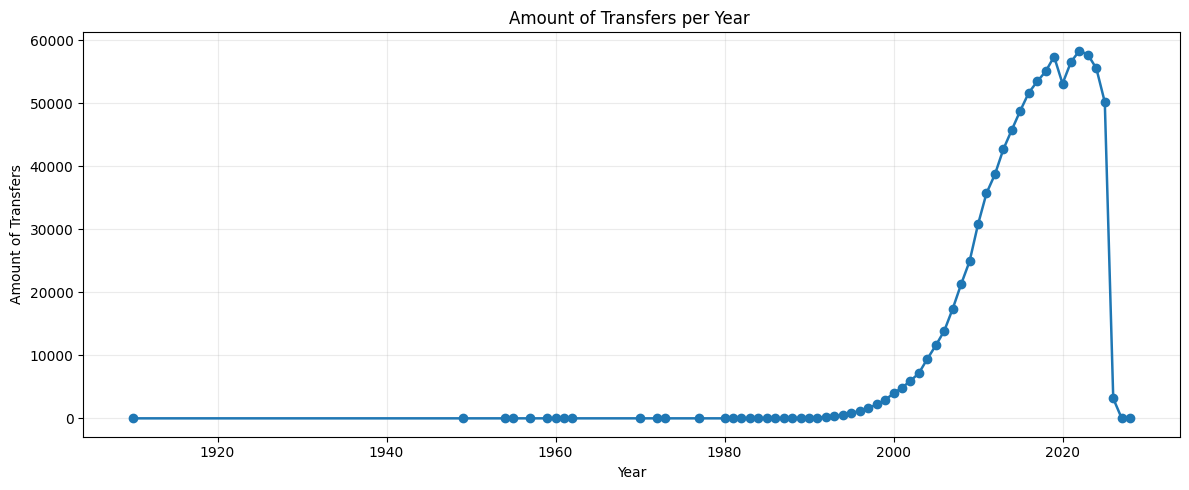

In [72]:
year_df = transfers[['details_date']].dropna().copy()
year_df['parsed_date'] = pd.to_datetime(pd.to_numeric(year_df['details_date'], errors='coerce'), unit='D', origin='1970-01-01', errors='coerce')

year_counts = (
    year_df['parsed_date']
    .dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values, marker='o', linewidth=1.8)
plt.title('Amount of Transfers per Year ')
plt.xlabel('Year')
plt.ylabel('Amount of Transfers')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [73]:
_tmp = transfers[['details_date','details_age','typeDetails_type','transferSource_competitionId','transferDestination_competitionId']].copy()
_tmp['parsed_date'] = pd.to_datetime(pd.to_numeric(_tmp['details_date'], errors='coerce'), unit='D', origin='1970-01-01', errors='coerce')
_tmp.sort_values('details_date', ascending=True).head(20)[['details_date','parsed_date','details_age','typeDetails_type','transferSource_competitionId','transferDestination_competitionId']]


,details_date,parsed_date,details_age,typeDetails_type,transferSource_competitionId,transferDestination_competitionId
5175,-21735.0,1910-06-30,75.0,RETURNED_FROM_PREVIOUS_LOAN,UNKNOWN_COMPETITION,UNKNOWN_COMPETITION
324677,-7489.0,1949-07-01,24.0,STANDARD,UNKNOWN_COMPETITION,UNKNOWN_COMPETITION
324678,-5663.0,1954-07-01,29.0,STANDARD,UNG1,UNG1
126731,-5298.0,1955-07-01,16.0,STANDARD,UNKNOWN_CLUB,UNKNOWN_COMPETITION
324679,-4567.0,1957-07-01,32.0,STANDARD,UNKNOWN_COMPETITION,NL1
324680,-3837.0,1959-07-01,34.0,STANDARD,NL1,UNKNOWN_COMPETITION
610220,-3837.0,1959-07-01,21.0,STANDARD,IT1,IT3A
126732,-3653.0,1960-01-01,20.0,STANDARD,UNKNOWN_COMPETITION,UNKNOWN_CLUB
610221,-3106.0,1961-07-01,23.0,STANDARD,UNKNOWN_COMPETITION,UNKNOWN_COMPETITION
126733,-2922.0,1962-01-01,22.0,STANDARD,UNKNOWN_CLUB,UNKNOWN_COMPETITION


we can see here that a lot of the transfers from very early years are not complete or look more like outliers than actual tranfers. We therefore need to cut off very early years as they seem like noise. Lets have a look at these early seasons and see how much value we have there and how much of the data is actually complete.

In [74]:
_cov = transfers[['details_date','transferSource_competitionId','transferDestination_competitionId']].copy()
_cov['parsed_date'] = pd.to_datetime(pd.to_numeric(_cov['details_date'], errors='coerce'), unit='D', origin='1970-01-01', errors='coerce')
_cov['year'] = _cov['parsed_date'].dt.year
_cov['both_present'] = (
    _cov['transferSource_competitionId'].notna()
    & _cov['transferDestination_competitionId'].notna()
    & _cov['transferSource_competitionId'].astype(str).str.strip().ne('')
    & _cov['transferDestination_competitionId'].astype(str).str.strip().ne('')
)
cov2 = (_cov.groupby('year', dropna=True)
        .agg(n_transfers=('year','size'), both_present_share=('both_present','mean'))
        .reset_index()
        .sort_values('year'))
cov2.head(40)


,year,n_transfers,both_present_share
0,1910.0,1,1.0
1,1949.0,1,1.0
2,1954.0,1,1.0
3,1955.0,1,1.0
4,1957.0,1,1.0
5,1959.0,2,1.0
6,1960.0,1,1.0
7,1961.0,1,1.0
8,1962.0,2,1.0
9,1970.0,1,1.0


This shows, that the data starts to look reasonable and usable from 1995 onwards, with good transfer volume and coverage. Therefore we will cut-off the data before 1995. 

Lets handle the "future" data now

In [75]:
_tmp = transfers[['details_date','details_age','typeDetails_type','transferSource_competitionId','transferDestination_competitionId']].copy()
_tmp['parsed_date'] = pd.to_datetime(pd.to_numeric(_tmp['details_date'], errors='coerce'), unit='D', origin='1970-01-01', errors='coerce')
_tmp.sort_values('details_date', ascending=False).head(20)[['details_date','parsed_date','details_age','typeDetails_type','transferSource_competitionId','transferDestination_competitionId']]


,details_date,parsed_date,details_age,typeDetails_type,transferSource_competitionId,transferDestination_competitionId
909815,385876.0,NaT,1021.0,RETURNED_FROM_PREVIOUS_LOAN,IT3B,IT2
718800,21502.0,2028-11-14,29.0,STANDARD,UNKNOWN_COMPETITION,WITHOUT_CLUB
756664,20999.0,2027-06-30,23.0,RETURNED_FROM_PREVIOUS_LOAN,RLN4,RLB3
60621,20970.0,2027-06-01,40.0,STANDARD,UNKNOWN_COMPETITION,RETIREMENT
811841,20968.0,2027-05-30,24.0,RETURNED_FROM_PREVIOUS_LOAN,UNKNOWN_COMPETITION,TR1
659624,20966.0,2027-05-28,24.0,STANDARD,UNKNOWN_COMPETITION,WITHOUT_CLUB
742221,20954.0,2027-05-16,25.0,RETURNED_FROM_PREVIOUS_LOAN,RSK1,RSK1
867099,20818.0,2026-12-31,23.0,RETURNED_FROM_PREVIOUS_LOAN,ARGC,ARGC
916686,20818.0,2026-12-31,26.0,RETURNED_FROM_PREVIOUS_LOAN,AR3D,ARG2
41872,20818.0,2026-12-31,21.0,RETURNED_FROM_PREVIOUS_LOAN,AR3D,CLPF


these are actually mostly planend returns from loans but we do not want to map them  as they did not happen yet. 

we now set a hard analysis window: we remove everything after 2026-01-27 (dataset handover date), and everything before 1995 due to sparse/incomplete early coverage. then we map to seasons with a simple july cutoff heuristic.

In [76]:
ANALYSIS_START = pd.Timestamp('1995-01-01')
ANALYSIS_END = pd.Timestamp('2026-01-27')

if 'details_date_parsed' not in transfers.columns:
    transfers['details_date_parsed'] = pd.to_datetime(
        pd.to_numeric(transfers['details_date'], errors='coerce'),
        unit='D',
        origin='1970-01-01',
        errors='coerce'
    )

transfers_model = transfers[
    transfers['details_date_parsed'].between(ANALYSIS_START, ANALYSIS_END)
].copy()

def map_season(dt):
    if pd.isna(dt):
        return None
    y = dt.year
    return f'{y}/{y+1}' if dt.month >= 7 else f'{y-1}/{y}'

transfers_model['season'] = transfers_model['details_date_parsed'].apply(map_season)

print('rows before:', len(transfers))
print('rows after :', len(transfers_model))
print('date range :', transfers_model['details_date_parsed'].min(), '->', transfers_model['details_date_parsed'].max())
transfers_model[['details_date_parsed', 'season']].head()


rows before: 925322
rows after : 921332
date range : 1995-01-01 00:00:00 -> 2026-01-25 00:00:00


,details_date_parsed,season
0,1998-07-01,1998/1999
1,1999-07-01,1999/2000
2,2004-07-01,2004/2005
3,2007-07-01,2007/2008
4,2011-07-01,2011/2012


## 3 Cleaning of transfer tables

In [ ]:
# Continue with one consistent working dataframe
transfers_prep = transfers_model.copy()

# Keep parsed date as datetime and derive helper features once
transfers_prep['details_date_parsed'] = pd.to_datetime(transfers_prep['details_date_parsed'], errors='coerce')
transfers_prep['transfer_type_norm'] = transfers_prep['typeDetails_type'].astype(str).str.strip().str.lower()
transfers_prep['is_loan'] = transfers_prep['transfer_type_norm'].str.contains('loan', na=False)
transfers_prep['details_fee_value'] = pd.to_numeric(transfers_prep['details_fee_value'], errors='coerce')

# Drop temporary helper columns from earlier imputation diagnostics if they exist
helper_cols = [
    'src_n_unique_comp', 'src_single_comp', 'src_comp_imputed',
    'dst_n_unique_comp', 'dst_single_comp', 'dst_comp_imputed'
]
transfers_prep = transfers_prep.drop(columns=[c for c in helper_cols if c in transfers_prep.columns], errors='ignore')

# Ensure competition IDs are clean strings
for c in ['transferSource_competitionId', 'transferDestination_competitionId']:
    transfers_prep[c] = transfers_prep[c].astype(str).str.strip()
    transfers_prep.loc[transfers_prep[c].isin(['', 'nan', 'None']), c] = 'UNKNOWN_COMPETITION'

pd.DataFrame({
    'rows_total': [len(transfers_prep)],
    'src_unknown_share': [transfers_prep['transferSource_competitionId'].eq('UNKNOWN_COMPETITION').mean()],
    'dst_unknown_share': [transfers_prep['transferDestination_competitionId'].eq('UNKNOWN_COMPETITION').mean()],
    'date_min': [transfers_prep['details_date_parsed'].min()],
    'date_max': [transfers_prep['details_date_parsed'].max()],
})

## 4 Map competitions

In [ ]:
mapping_path = PROJECT_ROOT / 'data' / 'competition_mapping.csv'
comp_map = pd.read_csv(mapping_path)

# Normalize key mapping columns
comp_map['competition_id'] = comp_map['competition_id'].astype(str).str.strip()
for col in ['canonical_competition_id', 'prior_league_names']:
    if col in comp_map.columns:
        comp_map[col] = comp_map[col].fillna('-')

comp_map.head()

In [ ]:
# Build strict and with_unknown variants after preprocessing
transfers_with_unknown = transfers_prep.copy()

src_unknown = transfers_with_unknown['transferSource_competitionId'].eq('UNKNOWN_COMPETITION')
dst_unknown = transfers_with_unknown['transferDestination_competitionId'].eq('UNKNOWN_COMPETITION')
transfers_strict = transfers_with_unknown.loc[~(src_unknown | dst_unknown)].copy()

comp_map_src = comp_map.rename(columns={
    'competition_id': 'transferSource_competitionId',
    'league_name': 'source_league',
    'country_id': 'source_country_id',
    'tier': 'source_tier',
    'canonical_competition_id': 'source_canonical_id',
})

comp_map_dst = comp_map.rename(columns={
    'competition_id': 'transferDestination_competitionId',
    'league_name': 'dest_league',
    'country_id': 'dest_country_id',
    'tier': 'dest_tier',
    'canonical_competition_id': 'dest_canonical_id',
})

def build_edges(df):
    edges_base = (
        df
        .merge(comp_map_src, on='transferSource_competitionId', how='left')
        .merge(comp_map_dst, on='transferDestination_competitionId', how='left')
    )

    edges_base['source_league_id'] = edges_base['transferSource_competitionId']
    edges_base['dest_league_id'] = edges_base['transferDestination_competitionId']
    edges_base['is_domestic'] = edges_base['transferSource_countryId'] == edges_base['transferDestination_countryId']

    # Keep mapped labels where available; special states remain readable
    edges_base['source_league'] = edges_base['source_league'].fillna(edges_base['transferSource_competitionId'])
    edges_base['dest_league'] = edges_base['dest_league'].fillna(edges_base['transferDestination_competitionId'])

    edge_season = (
        edges_base
        .groupby(
            [
                'season', 'source_league_id', 'dest_league_id', 'source_league', 'dest_league',
                'source_country_id', 'dest_country_id', 'source_tier', 'dest_tier'
            ],
            dropna=False
        )
        .agg(
            n_transfers=('details_playerId', 'count'),
            n_loans=('is_loan', 'sum'),
            fee_sum=('details_fee_value', 'sum'),
            fee_median=('details_fee_value', 'median'),
            domestic_share=('is_domestic', 'mean')
        )
        .reset_index()
    )

    edge_all = (
        edges_base
        .groupby(
            [
                'source_league_id', 'dest_league_id', 'source_league', 'dest_league',
                'source_country_id', 'dest_country_id', 'source_tier', 'dest_tier'
            ],
            dropna=False
        )
        .agg(
            n_transfers=('details_playerId', 'count'),
            n_loans=('is_loan', 'sum'),
            fee_sum=('details_fee_value', 'sum'),
            fee_median=('details_fee_value', 'median'),
            domestic_share=('is_domestic', 'mean')
        )
        .reset_index()
    )
    return edge_all, edge_season

edge_all_with_unknown, edge_season_with_unknown = build_edges(transfers_with_unknown)
edge_all_strict, edge_season_strict = build_edges(transfers_strict)

pd.DataFrame({
    'variant': ['with_unknown', 'strict'],
    'transfer_rows': [len(transfers_with_unknown), len(transfers_strict)],
    'edge_all_rows': [len(edge_all_with_unknown), len(edge_all_strict)],
    'edge_season_rows': [len(edge_season_with_unknown), len(edge_season_strict)],
})

## 05 Edge lists

In [ ]:
# Export edge lists for the analysis notebook
out_dir = PROJECT_ROOT / 'data' / 'prepared'
out_dir.mkdir(parents=True, exist_ok=True)

paths = {
    'edge_all_with_unknown': out_dir / 'edge_all_with_unknown.csv',
    'edge_season_with_unknown': out_dir / 'edge_season_with_unknown.csv',
    'edge_all_strict': out_dir / 'edge_all_strict.csv',
    'edge_season_strict': out_dir / 'edge_season_strict.csv',
}

edge_all_with_unknown.to_csv(paths['edge_all_with_unknown'], index=False)
edge_season_with_unknown.to_csv(paths['edge_season_with_unknown'], index=False)
edge_all_strict.to_csv(paths['edge_all_strict'], index=False)
edge_season_strict.to_csv(paths['edge_season_strict'], index=False)

pd.DataFrame([
    {'file': str(paths['edge_all_with_unknown']), 'rows': len(edge_all_with_unknown), 'cols': edge_all_with_unknown.shape[1]},
    {'file': str(paths['edge_season_with_unknown']), 'rows': len(edge_season_with_unknown), 'cols': edge_season_with_unknown.shape[1]},
    {'file': str(paths['edge_all_strict']), 'rows': len(edge_all_strict), 'cols': edge_all_strict.shape[1]},
    {'file': str(paths['edge_season_strict']), 'rows': len(edge_season_strict), 'cols': edge_season_strict.shape[1]},
])

In [ ]:
# ── Descriptive Data Table ──────────────────────────────────────────────────
# Season span (from cleaned model set)
season_min = transfers_prep["season"].min()
season_max = transfers_prep["season"].max()
n_seasons  = transfers_prep["season"].nunique()

# Record counts
n_raw    = len(transfers_prep)
n_strict = len(transfers_strict)

# Transfer-type split (raw model set)
loan_n = int(transfers_prep["is_loan"].sum())
perm_n = n_raw - loan_n

# Unique leagues & countries — use name columns (ID column has canonical aliases)
_PSEUDO = {"WITHOUT_CLUB", "RETIREMENT", "UNKNOWN_CLUB", "CAREER_BREAK"}
_real   = edge_all_strict[
    ~edge_all_strict["source_league"].isin(_PSEUDO) &
    ~edge_all_strict["dest_league"].isin(_PSEUDO)
]
n_leagues = len(set(_real["source_league"]) | set(_real["dest_league"]))
n_countries = len(
    set(pd.to_numeric(_real["source_country_id"], errors="coerce").dropna())
    | set(pd.to_numeric(_real["dest_country_id"], errors="coerce").dropna())
)

desc_table = pd.DataFrame([
    {"Dimension": "Analysis window",                      "Value": f"{season_min} – {season_max}"},
    {"Dimension": "Seasons",                              "Value": n_seasons},
    {"Dimension": "Transfer records (1995–2026, clean)",  "Value": f"{n_raw:,}"},
    {"Dimension": "Records with both leagues mapped",     "Value": f"{n_strict:,}"},
    {"Dimension": "Unique leagues (strict)",              "Value": n_leagues},
    {"Dimension": "Unique countries (strict)",            "Value": n_countries},
    {"Dimension": "Loan transfers",                       "Value": f"{loan_n:,} ({loan_n/n_raw:.1%})"},
    {"Dimension": "Permanent transfers",                  "Value": f"{perm_n:,} ({perm_n/n_raw:.1%})"},
])
desc_table